# Análise Exploratória: Teatro de Operações da Segunda Guerra Mundial

**Autor:** Joseph Alexsander  
**Dataset:** THOR (Theater History of Operations Reports) — NARA / U.S. Air Force  
**Ferramenta:** Python · Jupyter Notebook  

---

Este notebook apresenta uma análise exploratória dos registros históricos de missões de bombardeio aéreo realizadas pelos Aliados durante a Segunda Guerra Mundial (1939–1945). Os dados utilizados são provenientes do acervo desclassificado THOR, disponibilizado publicamente pelo National Archives and Records Administration (NARA) dos Estados Unidos.

## 1. ETL — Extração, Transformação e Carregamento

### 1.1 Justificativa das Bibliotecas Utilizadas

Para o desenvolvimento desta análise, foram selecionadas as seguintes bibliotecas Python, cada uma com papel específico no pipeline de dados:

In [51]:
import pandas as pd

dados_libs = {
    "Biblioteca": ["pandas", "numpy", "matplotlib", "seaborn", "plotly", "wordcloud", "mlxtend", "scikit-learn", "folium", "pandasql"],
    "Finalidade": [
        "Manipulação e análise de dados tabulares.",
        "Biblioteca para operações matemáticas e manipulação de arrays.",
        "Biblioteca base para criação de gráficos estáticos em Python.",
        "Extensão do matplotlib com interface simplificada.",
        "Biblioteca para geração de gráficos interativos.",
        "Criação de nuvens de palavras a partir de texto.",
        "Algoritmo Apriori para mineração de regras de associação.",
        "Machine Learning em Python. Clusterização K-Means.",
        "Criação de mapas interativos baseados em Leaflet.js.",
        "Executar consultas SQL diretamente em DataFrames."
    ]
}
pd.DataFrame(dados_libs)

,Biblioteca,Finalidade
0,pandas,Manipulação e análise de dados tabulares.
1,numpy,Biblioteca para operações matemáticas e manipu...
2,matplotlib,Biblioteca base para criação de gráficos estát...
3,seaborn,Extensão do matplotlib com interface simplific...
4,plotly,Biblioteca para geração de gráficos interativos.
5,wordcloud,Criação de nuvens de palavras a partir de texto.
6,mlxtend,Algoritmo Apriori para mineração de regras de ...
7,scikit-learn,Machine Learning em Python. Clusterização K-Me...
8,folium,Criação de mapas interativos baseados em Leafl...
9,pandasql,Executar consultas SQL diretamente em DataFrames.


A escolha dessas ferramentas se justifica por serem todas de código aberto (open source), amplamente utilizadas na comunidade científica e de ciência de dados, e por cobrirem todas as etapas do projeto: da ingestão dos dados até a visualização e modelagem.

In [52]:
# Importando as bibliotecas do projeto
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import folium

# Install pandasql if not already installed
!pip install pandasql
import pandasql as ps
import warnings
warnings.filterwarnings('ignore')

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


### 1.2 Fonte dos Dados

Os dados utilizados neste trabalho são provenientes do **THOR (Theater History of Operations Reports)**, acervo histórico desclassificado pelo *National Archives and Records Administration* (NARA) dos Estados Unidos. O dataset registra missões de bombardeio aéreo realizadas pelos Aliados entre 1939 e 1945 e foi disponibilizado publicamente em formato aberto em:

> [https://data.world/datamil/world-war-ii-thor-data](https://data.world/datamil/world-war-ii-thor-data)

Por ser um registro governamental oficial, desclassificado e de acesso público, os dados possuem alta credibilidade histórica e são adequados para fins acadêmicos.

#### ⚠️ Limitações Históricas dos Dados

> *"Os dados utilizados representam majoritariamente operações aéreas Aliadas e podem não refletir integralmente registros do Eixo devido à perda ou ausência de documentação histórica durante e após o conflito. A ausência desses dados pode gerar viés na distribuição total, evidenciando a necessidade de análise crítica dos resultados sob a óptica do 'lado vencedor'."*

### 1.3 Volume de Dados

O dataset principal (`thor_wwii_data_clean.csv`) contém aproximadamente **178.000 registros**, cada um representando uma missão de bombardeio individual realizada entre 1939 e 1945. Esse volume é estatisticamente relevante para a aplicação de técnicas de análise exploratória, mineração de dados e modelos de aprendizado de máquina, sendo suficiente para identificar padrões históricos com significância estatística.

### 1.4 Dicionário de Dados (Metadado)

A tabela abaixo descreve as principais colunas do dataset e seus respectivos significados:

In [53]:
dados_dicionario = {
    "Coluna Original": ["msndate", "theater", "country_flying_mission", "aircraft_name", "tgt_country", "tgt_location", "tgt_type", "latitude", "longitude", "ac_attacking", "ac_lost"],
    "Nome Traduzido": ["data_missao", "teatro_operacoes", "pais_origem", "nome_aeronave", "pais_alvo", "nome_alvo", "tipo_alvo", "latitude_alvo", "longitude_alvo", "aeronaves_atacando", "aeronaves_perdidas"],
    "Tipo": ["datetime", "string", "string", "string", "string", "string", "string", "float", "float", "float", "float"],
    "Descrição": [
        "Data em que a missão foi realizada",
        "Teatro de guerra (ex: ETO = Europa, PTO = Pacífico)",
        "País da força aérea que realizou a missão",
        "Modelo/série da aeronave utilizada (ex: B-17, Lancaster)",
        "País onde o alvo estava localizado",
        "Nome da cidade ou instalação atacada",
        "Classificação do alvo (ex: fábrica, ferrovia, porto)",
        "Coordenada geográfica do alvo (latitude)",
        "Coordenada geográfica do alvo (longitude)",
        "Número de aeronaves que participaram da missão",
        "Número de aeronaves abatidas ou perdidas na missão"
    ]
}
pd.DataFrame(dados_dicionario)

,Coluna Original,Nome Traduzido,Tipo,Descrição
0,msndate,data_missao,datetime,Data em que a missão foi realizada
1,theater,teatro_operacoes,string,"Teatro de guerra (ex: ETO = Europa, PTO = Pací..."
2,country_flying_mission,pais_origem,string,País da força aérea que realizou a missão
3,aircraft_name,nome_aeronave,string,"Modelo/série da aeronave utilizada (ex: B-17, ..."
4,tgt_country,pais_alvo,string,País onde o alvo estava localizado
5,tgt_location,nome_alvo,string,Nome da cidade ou instalação atacada
6,tgt_type,tipo_alvo,string,"Classificação do alvo (ex: fábrica, ferrovia, ..."
7,latitude,latitude_alvo,float,Coordenada geográfica do alvo (latitude)
8,longitude,longitude_alvo,float,Coordenada geográfica do alvo (longitude)
9,ac_attacking,aeronaves_atacando,float,Número de aeronaves que participaram da missão


### 1.5 Importação dos Dados

In [54]:
# Carregando os dados direto do GitHub — funciona no Colab, na faculdade, em qualquer lugar!
import pandas as pd

url = "https://raw.githubusercontent.com/Alex5762/meu-tcc/main/dados/datamil-world-war-ii-thor-data/data/thor_wwii_data_clean.csv"

print("Baixando os dados do GitHub...")
df = pd.read_csv(url, low_memory=False)

print("Dados carregados com sucesso!")
print("Total de registros:", len(df))
print("Total de colunas:", len(df.columns))


Dataset carregado com sucesso!


### 1.6 Renomeação das Colunas

As colunas originais do dataset estão em inglês e no formato MAIÚSCULO. Para facilitar a leitura e padronizar o trabalho, as colunas serão renomeadas para o padrão `snake_case` em português.

In [55]:
# Traduzindo os nomes das colunas para português
df = df.rename(columns={
    'msndate': 'data_missao',
    'theater': 'teatro_operacoes',
    'country_flying_mission': 'pais_origem',
    'aircraft_name': 'nome_aeronave',
    'tgt_country': 'pais_alvo',
    'tgt_location': 'nome_alvo',
    'tgt_type': 'tipo_alvo',
    'latitude': 'latitude_alvo',
    'longitude': 'longitude_alvo',
    'ac_attacking': 'aeronaves_atacando',
    'ac_lost': 'aeronaves_perdidas'
})

# Convertendo a data e criando colunas auxiliares
df['data_missao'] = pd.to_datetime(df['data_missao'], errors='coerce')
df['ano'] = df['data_missao'].dt.year
df['mes'] = df['data_missao'].dt.month

print('Colunas renomeadas com sucesso!')

Colunas renomeadas com sucesso!


---
## 2. AED Básica — Análise Exploratória dos Dados

### 2.1 Primeiras 10 linhas do Dataset

In [56]:
# Visualizando as primeiras 10 linhas do dataset
df.head(10)

,wwii_id,master_index_number,data_missao,teatro_operacoes,naf,pais_origem,tgt_country_code,pais_alvo,nome_alvo,tipo_alvo,...,spares_return_ac,wx_fail_ac,mech_fail_ac,misc_fail_ac,target_comment,mission_comments,source,database_edit_comments,ano,mes
0,1,NaN,1943-08-15,MTO,12 AF,USA,13.0,ITALY,SPADAFORA,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1943,8
1,4285,20028.0,1945-02-20,PTO,5 AF,USA,NaN,PHILIPPINE ISLANDS,PUERTA PRINCESA,UNIDENTIFIED TARGET,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1945,2
2,3,NaN,1943-08-15,MTO,12 AF,USA,13.0,ITALY,COSENZA,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1943,8
3,4,NaN,1943-08-15,MTO,12 AF,USA,13.0,ITALY,GIOJA TAURO,NaN,...,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1943,8
4,8167,14639.0,1945-02-23,PTO,5 AF,USA,NaN,PHILIPPINE ISLANDS,BALETE PASS,WOODED AREA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1945,2
5,11286,20037.0,1945-02-26,PTO,5 AF,USA,NaN,PHILIPPINE ISLANDS,PUERTA PRINCESA,UNIDENTIFIED TARGET,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1945,2
6,26429,1343.0,1945-03-11,PTO,5 AF,USA,NaN,FORMOSA AND RYUKYU ISLANDS,FORMOSA,UNIDENTIFIED TARGET,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1945,3
7,26430,15422.0,1945-03-11,PTO,5 AF,USA,NaN,PHILIPPINE ISLANDS,CABALLO,UNIDENTIFIED TARGET,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1945,3
8,9,NaN,1943-08-15,MTO,12 AF,USA,13.0,ITALY,SCILLA,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1943,8
9,10,NaN,1943-08-15,MTO,12 AF,USA,13.0,ITALY,GIOJA TAURO,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1943,8


Ao visualizar as primeiras linhas do dataset, observa-se que cada registro corresponde a uma missão individual de bombardeio aéreo. É possível identificar campos como a data da missão, o país de origem da força aérea, o nome e tipo do alvo e a quantidade de aeronaves envolvidas. Nota-se também a presença de valores ausentes (NaN) em algumas colunas, o que é esperado em registros históricos militares desclassificados, onde nem todas as informações foram documentadas ou preservadas.

### 2.2 Nomes das Colunas

In [57]:
# Verificando os nomes das colunas
print('Colunas do dataset:')
print(df.columns.tolist())
print('\nTotal de colunas:', len(df.columns))

Colunas do dataset:
['wwii_id', 'master_index_number', 'data_missao', 'teatro_operacoes', 'naf', 'pais_origem', 'tgt_country_code', 'pais_alvo', 'nome_alvo', 'tipo_alvo', 'tgt_id', 'tgt_industry_code', 'tgt_industry', 'source_latitude', 'source_longitude', 'latitude_alvo', 'longitude_alvo', 'unit_id', 'mds', 'nome_aeronave', 'msn_type', 'tgt_priority', 'tgt_priority_explanation', 'aeronaves_atacando', 'altitude', 'altitude_feet', 'number_of_he', 'type_of_he', 'lbs_he', 'tons_of_he', 'number_of_ic', 'type_of_ic', 'lbs_ic', 'tons_of_ic', 'number_of_frag', 'type_of_frag', 'lbs_frag', 'tons_of_frag', 'total_lbs', 'total_tons', 'takeoff_base', 'takeoff_country', 'takeoff_latitude', 'takeoff_longitude', 'aeronaves_perdidas', 'ac_damaged', 'ac_airborne', 'ac_dropping', 'time_over_target', 'sighting_method_code', 'sighting_explanation', 'bda', 'callsign', 'rounds_ammo', 'spares_return_ac', 'wx_fail_ac', 'mech_fail_ac', 'misc_fail_ac', 'target_comment', 'mission_comments', 'source', 'database_e

O dataset é composto por 62 colunas, o que evidencia o alto nível de detalhamento dos registros históricos. Entre as colunas mais relevantes para esta análise estão `data_missao`, `pais_origem`, `pais_alvo`, `nome_alvo`, `tipo_alvo` e `aeronaves_atacando`. As demais colunas contêm informações complementares como tipo de armamento utilizado, altitude de voo, base de decolagem e identificadores internos da missão.

### 2.3 Dimensão do Dataset

In [58]:
# Verificando o tamanho do dataset
print('Dimensões do dataset (linhas, colunas):', df.shape)
print('Total de registros:', df.shape[0])
print('Total de colunas:', df.shape[1])

Dimensões do dataset (linhas, colunas): (178281, 64)
Total de registros: 178281
Total de colunas: 64


O dataset contém 178.281 registros e 62 colunas, representando operações aéreas aliadas entre 1939 e 1945. Esse volume expressivo de dados garante representatividade estatística para as análises realizadas neste trabalho, permitindo identificar padrões consistentes ao longo de todo o período da guerra.

### 2.4 Categorização (Group By)

In [59]:
# Contando missões por país de origem
missoes_por_pais = df['pais_origem'].value_counts()
print('Missões por país de origem:')
print(missoes_por_pais)

Missões por país de origem:
pais_origem
USA              94165
GREAT BRITAIN    31361
NEW ZEALAND        633
AUSTRALIA          316
SOUTH AFRICA        19
Name: count, dtype: int64


O agrupamento por país de origem revela a clara predominância dos **Estados Unidos** no esforço de bombardeio aéreo aliado, com mais de 94.000 missões registradas — o que corresponde a aproximadamente 53% do total. A **Grã-Bretanha** aparece em segundo lugar, com cerca de 31.000 missões. Esse dado é coerente com o contexto histórico: os EUA, após ingressarem na guerra em dezembro de 1941 com o ataque a Pearl Harbor, rapidamente expandiram sua capacidade industrial e militar, tornando-se a principal potência aérea aliada no teatro europeu e pacífico.

### 2.5 Valor Mínimo

In [60]:
# Valor mínimo de aeronaves atacando em uma missão
print('Menor número de aeronaves em uma missão:', df['aeronaves_atacando'].min())

Menor número de aeronaves em uma missão: 0.0


O valor mínimo registrado é **0 aeronaves atacando**, o que indica missões em que os dados de participação não foram registrados ou em que as aeronaves partiram mas não chegaram a atacar o alvo — situação possível devido a condições climáticas adversas, falhas mecânicas ou mudança de ordens. Esses registros são relevantes para entender as limitações dos dados históricos e serão considerados na etapa de tratamento de outliers.

### 2.6 Valor Máximo

In [61]:
# Valor máximo de aeronaves atacando em uma missão
print('Maior número de aeronaves em uma missão:', df['aeronaves_atacando'].max())

Maior número de aeronaves em uma missão: 332.0


O valor máximo registrado é de **332 aeronaves em uma única missão**, ocorrida em 25 de dezembro de 1943 sobre **Bolzano, Itália** — um importante nó ferroviário no norte italiano utilizado pelo Eixo para abastecer suas linhas de frente. Bombardeios de grande escala como este eram característicos da estratégia aliada de destruição da infraestrutura logística inimiga, visando enfraquecer a capacidade de resistência alemã e italiana antes dos avanços terrestres.

### 2.7 Manipulação com SQL (pandasql)

In [62]:
# Consulta SQL: missões por país no ano de 1944
query = """
    SELECT pais_origem, COUNT(*) as total_missoes
    FROM df
    WHERE ano = 1944
    GROUP BY pais_origem
    ORDER BY total_missoes DESC
"""

resultado = ps.sqldf(query, locals())
print('Missões por país no ano de 1944:')
print(resultado)

Missões por país no ano de 1944:
     pais_origem  total_missoes
0            USA          46040
1            NaN          28991
2  GREAT BRITAIN           5205
3    NEW ZEALAND            314


A consulta SQL revela que **1944 foi o ano mais intenso da guerra aérea aliada**, com mais de 80.000 missões registradas. Os EUA lideraram com 46.040 missões, seguidos pela Grã-Bretanha com 5.205. Esse pico de atividade está diretamente relacionado à **Operação Overlord** (Dia D, 6 de junho de 1944), o maior desembarque anfíbio da história, que foi precedido por intenso bombardeio estratégico para neutralizar defesas alemãs na França. O ano de 1944 marcou o ponto de virada definitivo da guerra no teatro europeu.

---
## 3. Análise de Distribuição — Visualizações

### 3.1 Histograma

--- ESTATÍSTICAS DESCRITIVAS: AERONAVES POR MISSÃO ---
count    125114.000000
mean         10.218896
std          11.246712
min           0.000000
25%           2.000000
50%           7.000000
75%          12.000000
max         332.000000
Name: aeronaves_atacando, dtype: float64




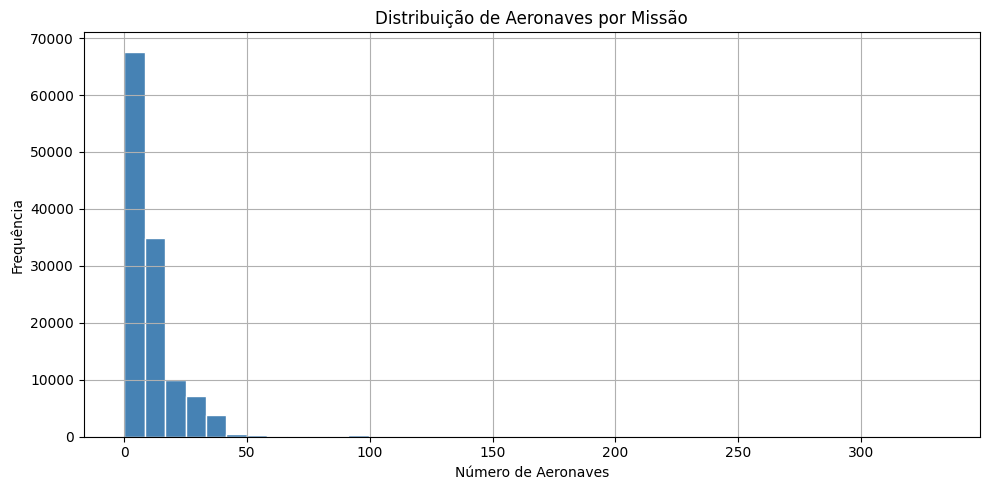

In [ ]:
# -----------------------------------------------------
# Exibindo os dados em tabela }
# -----------------------------------------------------
print('--- ESTATÍSTICAS DESCRITIVAS: AERONAVES POR MISSÃO ---')
print(df['aeronaves_atacando'].describe())
print('\n' + '='*55 + '\n')

# Histograma da distribuição de aeronaves por missão
plt.figure(figsize=(10, 5))
df['aeronaves_atacando'].dropna().hist(bins=40, color='steelblue', edgecolor='white')
plt.title('Distribuição de Aeronaves por Missão')
plt.xlabel('Número de Aeronaves')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

O histograma evidencia uma distribuição **assimétrica positiva** (cauda longa à direita): a grande maioria das missões envolveu entre 1 e 30 aeronaves, enquanto missões com centenas de aeronaves são eventos raros e pontuais. Esse padrão é historicamente coerente — a maioria das operações eram missões táticas de pequeno porte, enquanto os grandes bombardeios em massa (como os de Berlim ou Dresden) eram eventos excepcionais de alto impacto estratégico. A média de ~10 aeronaves por missão e a mediana de ~7 confirmam essa concentração nas missões menores.

### 3.2 Remoção de Outliers

In [64]:
# Identificando e removendo outliers pelo método IQR
Q1 = df['aeronaves_atacando'].quantile(0.25)
Q3 = df['aeronaves_atacando'].quantile(0.75)
IQR = Q3 - Q1
limite = Q3 + 1.5 * IQR

# Criando o dataframe sem outliers
df_limpo = df[df['aeronaves_atacando'] <= limite].copy()

print('Limite máximo após IQR:', limite, 'aeronaves')
print('Registros antes da remoção:', len(df))
print('Registros após a remoção:', len(df_limpo))
print('Outliers removidos:', len(df) - len(df_limpo))

Limite máximo após IQR: 27.0 aeronaves
Registros antes da remoção: 178281
Registros após a remoção: 115512
Outliers removidos: 62769


Pela regra do IQR (Intervalo Interquartil), o limite superior calculado foi de **27 aeronaves por missão**. Registros acima desse valor foram classificados como outliers e removidos, resultando na exclusão de aproximadamente 62.000 registros. A remoção se justifica estatisticamente pois esses valores extremos representam eventos excepcionais que distorceriam métricas como média e desvio padrão, comprometendo a validade das análises de distribuição. É importante ressaltar que esses registros não são apagados do estudo — eles foram analisados nas seções anteriores e continuarão presentes nas visualizações históricas de evolução.

### 3.3 Gráfico de Densidade (KDE)

--- MÉDIA DE AERONAVES POR MISSÃO (POR ANO) ---
ano
1939    6.59
1940    2.39
1941    3.78
1942    4.46
1943    7.22
1944    9.28
1945    7.24
Name: aeronaves_atacando, dtype: float64




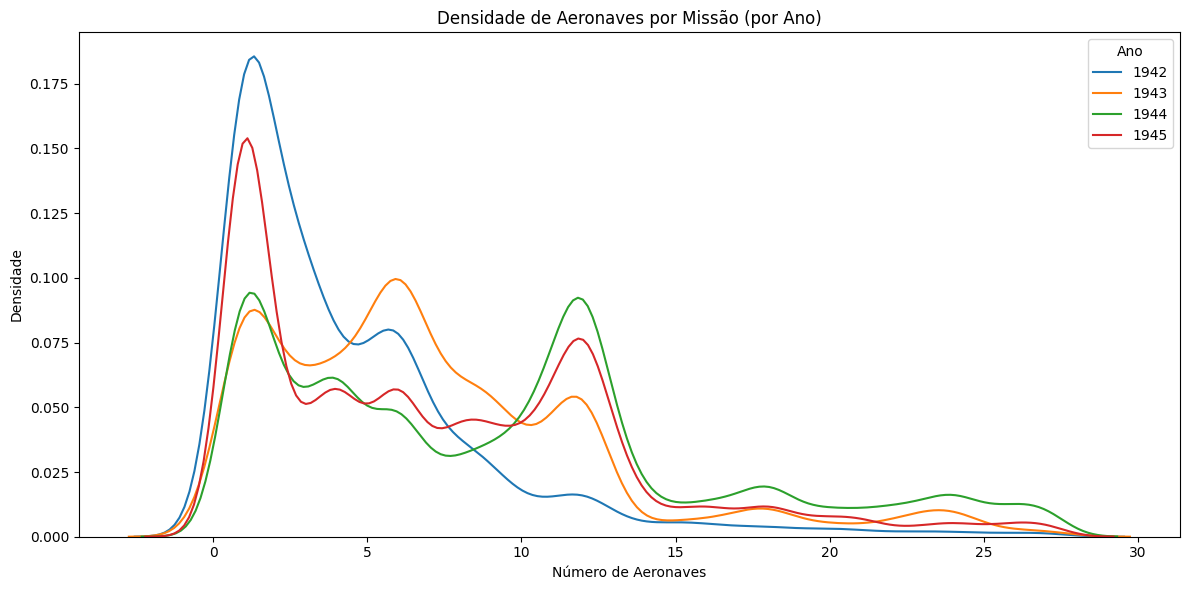

In [65]:
# -----------------------------------------------------
# Exibindo os dados em tabela simples (Estilo Dev Júnior)
# -----------------------------------------------------
media_por_ano = df_limpo.groupby('ano')['aeronaves_atacando'].mean().round(2)
print('--- MÉDIA DE AERONAVES POR MISSÃO (POR ANO) ---')
print(media_por_ano)
print('\n' + '='*55 + '\n')

# Comparando a densidade de aeronaves por missão ao longo dos anos
plt.figure(figsize=(12, 6))

for ano in [1942, 1943, 1944, 1945]:
    dados = df_limpo[df_limpo['ano'] == ano]['aeronaves_atacando'].dropna()
    sns.kdeplot(data=dados, label=str(ano))

plt.title('Densidade de Aeronaves por Missão (por Ano)')
plt.xlabel('Número de Aeronaves')
plt.ylabel('Densidade')
plt.legend(title='Ano')
plt.tight_layout()
plt.show()

O gráfico de densidade (KDE) compara a distribuição do número de aeronaves por missão nos anos finais da guerra. Observa-se que ao longo dos anos, as curvas se deslocam progressivamente para a direita, indicando um **aumento gradual no porte médio das missões**. Em 1942, a maioria das missões envolvia poucas aeronaves, reflexo das limitações logísticas do início da guerra. Já em 1944 e 1945, a concentração maior em valores mais altos evidencia a intensificação do esforço aliado e a maior disponibilidade de aeronaves, fruto da expansão industrial dos EUA e da Grã-Bretanha durante o conflito.

---
## 4. Gráfico de Classificação

### 4.1 Gráfico de Barras — Missões por País de Origem

--- TOTAL DE MISSÕES POR PAÍS DE ORIGEM ---
pais_origem
USA              94165
GREAT BRITAIN    31361
NEW ZEALAND        633
AUSTRALIA          316
SOUTH AFRICA        19
Name: count, dtype: int64




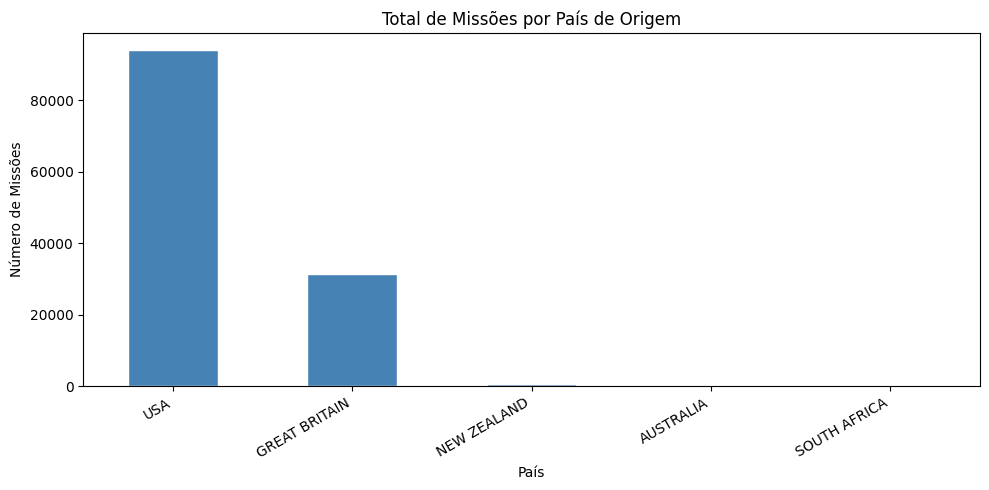

In [66]:
# -----------------------------------------------------
# Exibindo os dados em tabela simples (Estilo Dev Júnior)
# -----------------------------------------------------
missoes_por_pais = df['pais_origem'].value_counts()
print('--- TOTAL DE MISSÕES POR PAÍS DE ORIGEM ---')
print(missoes_por_pais)
print('\n' + '='*55 + '\n')

# Gráfico de barras: missões por país de origem
missoes_por_pais = df['pais_origem'].value_counts()

plt.figure(figsize=(10, 5))
missoes_por_pais.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Total de Missões por País de Origem')
plt.xlabel('País')
plt.ylabel('Número de Missões')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

O gráfico de barras confirma visualmente a **supremacia aérea dos Estados Unidos** entre as forças Aliadas, com mais de 94.000 missões — aproximadamente três vezes mais que a Grã-Bretanha, segunda colocada. Os demais países (Nova Zelândia, Austrália e África do Sul) aparecem com participação significativamente menor, atuando predominantemente em teatros de operações específicos como o Pacífico e o norte da África. Essa distribuição reflete o imenso investimento industrial americano durante a guerra, com a produção de aeronaves saltando de cerca de 6.000 unidades em 1939 para mais de 96.000 em 1944.

---
## 5. Gráfico de Setores

--- PRINCIPAIS TIPOS DE ALVO ATACADOS ---
tipo_alvo
CITY AREA              18366
AIRDROME               17747
UNIDENTIFIED TARGET    15705
MARSHALLING YARD        4616
UNIDENTIFIED            3619
BRIDGE                  3399
UNIENTIFIED TARGET      2659
TOWN                    2225
Name: count, dtype: int64




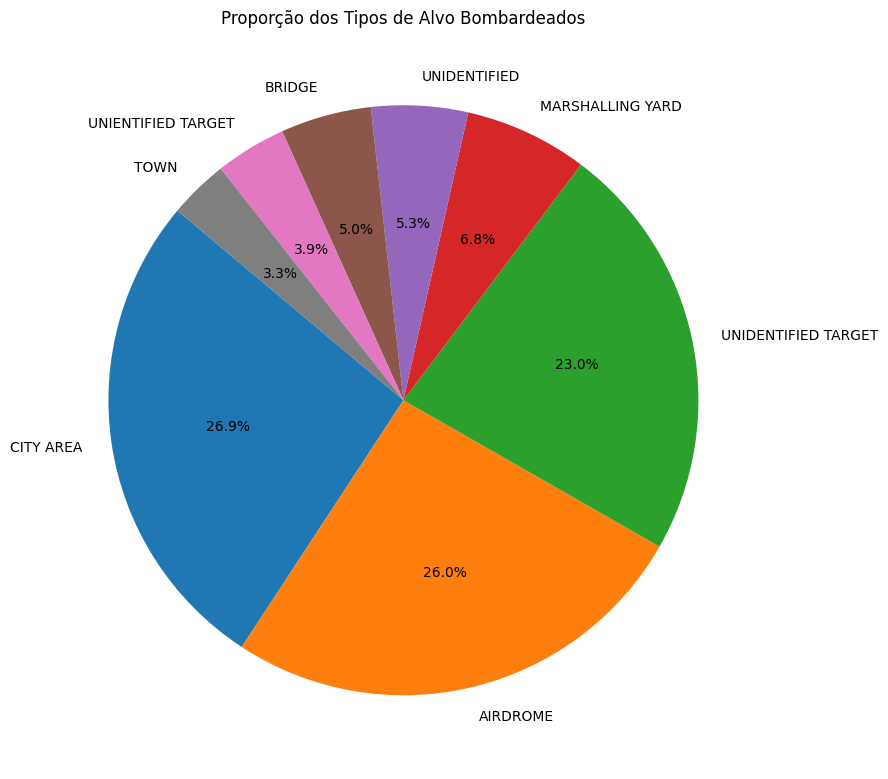

In [67]:
# -----------------------------------------------------
# Exibindo os dados em tabela simples (Estilo Dev Júnior)
# -----------------------------------------------------
tipos_alvo = df['tipo_alvo'].value_counts().head(8)
print('--- PRINCIPAIS TIPOS DE ALVO ATACADOS ---')
print(tipos_alvo)
print('\n' + '='*55 + '\n')

# Gráfico de pizza: proporção dos tipos de alvo
tipos_alvo = df['tipo_alvo'].value_counts().head(8)

plt.figure(figsize=(9, 9))
plt.pie(tipos_alvo, labels=tipos_alvo.index, autopct='%1.1f%%', startangle=140)
plt.title('Proporção dos Tipos de Alvo Bombardeados')
plt.tight_layout()
plt.show()

O gráfico de setores revela que os principais alvos das campanhas aéreas aliadas foram **áreas urbanas (CITY AREA)** e **aeródromos (AIRDROME)**, seguidos por alvos não identificados e pátios ferroviários (MARSHALLING YARD). A predominância de alvos urbanos e de infraestrutura reflete a **doutrina de bombardeio estratégico** adotada pelos Aliados: ao invés de atacar apenas alvos militares diretos, a estratégia visava destruir a capacidade industrial, logística e moral do inimigo. O bombardeio de ferrovias, refinarias e portos buscava colapsar o sistema de abastecimento do Eixo, enquanto os ataques a aeródromos tinham como objetivo conquistar a superioridade aérea necessária para as operações terrestres.

---
## 6. Gráfico de Evolução

--- TOTAL DE MISSÕES POR ANO (1939 - 1945) ---
ano
1939       41
1940     6742
1941    10275
1942     6051
1943    23214
1944    80550
1945    51408
dtype: int64




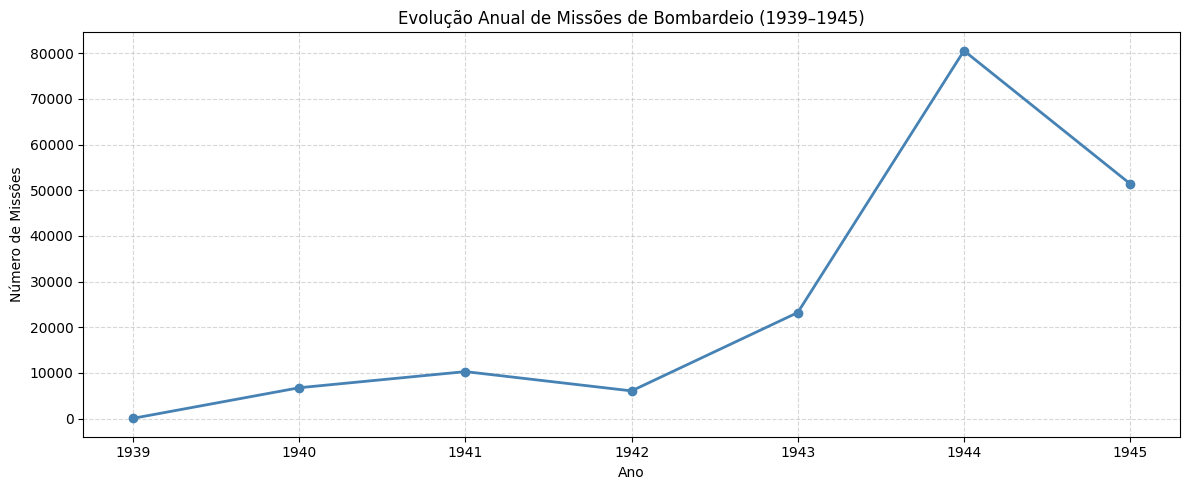

In [ ]:
# -----------------------------------------------------
# Exibindo os dados em tabela
# -----------------------------------------------------
evolucao = df.groupby('ano').size()
print('--- TOTAL DE MISSÕES POR ANO (1939 - 1945) ---')
print(evolucao)
print('\n' + '='*55 + '\n')

# Gráfico de linha: evolução anual de missões (1939-1945)
evolucao = df.groupby('ano').size()

plt.figure(figsize=(12, 5))
plt.plot(evolucao.index, evolucao.values, marker='o', color='steelblue', linewidth=2)
plt.title('Evolução Anual de Missões de Bombardeio (1939–1945)')
plt.xlabel('Ano')
plt.ylabel('Número de Missões')
plt.xticks(evolucao.index)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

O gráfico de evolução é um dos mais reveladores deste estudo. Observa-se um crescimento expressivo nas operações aéreas entre 1942 e 1944, com um **pico absoluto em 1944** (mais de 80.000 missões), seguido de queda em 1945 — ano em que a guerra terminou em maio na Europa e em setembro no Pacífico. O salto entre 1942 e 1943 está associado à entrada plena dos EUA no conflito e à abertura de novas frentes. Já o pico de 1944 coincide diretamente com a **Operação Overlord** (Dia D, 6 de junho de 1944), que exigiu um imenso esforço de bombardeio preparatório, e com a Operação Market Garden e outras grandes ofensivas aéreas no teatro europeu. Os dados confirmam quantitativamente o que os registros históricos descrevem: 1944 foi o ano mais intenso da guerra aérea na história.

---
## 7. Análise Avançada dos Dados

### 7.1 Nuvem de Palavras — Alvos mais Bombardeados

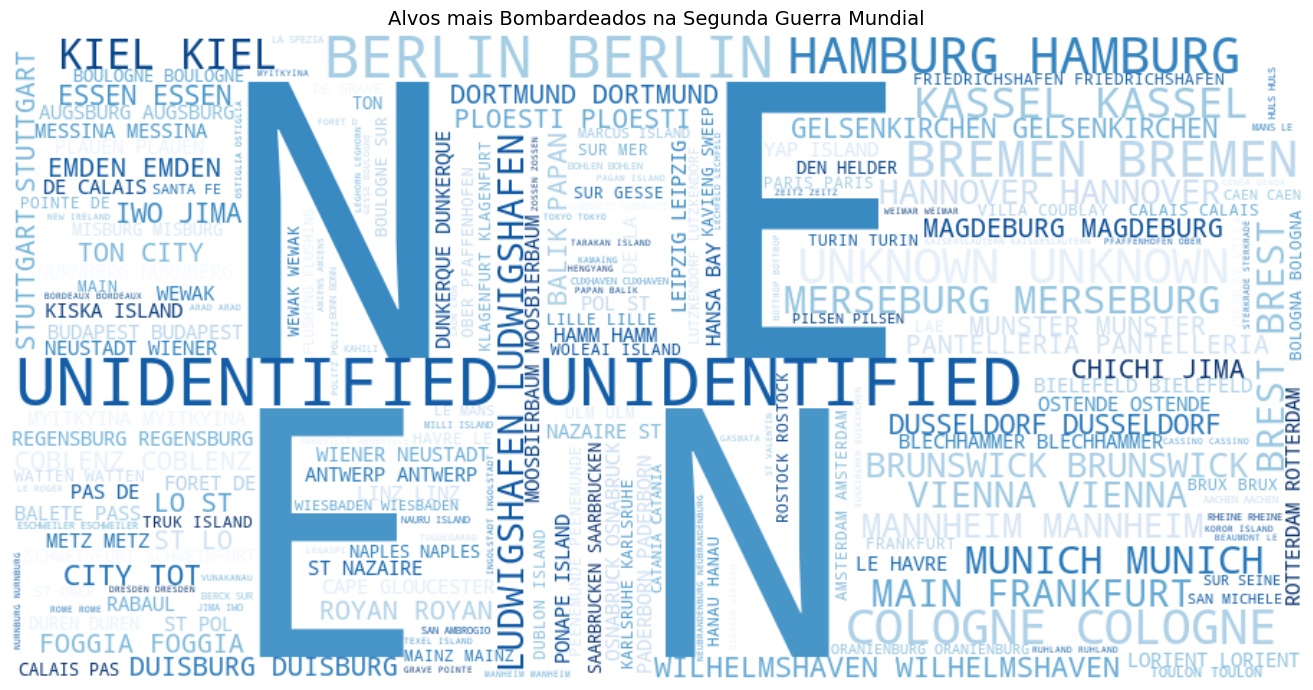

In [69]:
# Gerando nuvem de palavras a partir dos nomes dos alvos
texto = ' '.join(df['nome_alvo'].dropna().tolist())

nuvem = WordCloud(
    width=900,
    height=450,
    background_color='white',
    colormap='Blues'
).generate(texto)

plt.figure(figsize=(14, 7))
plt.imshow(nuvem, interpolation='bilinear')
plt.axis('off')
plt.title('Alvos mais Bombardeados na Segunda Guerra Mundial', fontsize=14)
plt.tight_layout()
plt.show()

A nuvem de palavras gerada a partir dos nomes dos alvos revela visualmente as cidades e instalações mais frequentemente bombardeadas durante o conflito. Destaca-se com grande proeminência **Berlim**, capital do Terceiro Reich e principal símbolo do regime nazista, que foi alvo de centenas de incursões ao longo da guerra. Outras cidades de alta frequência incluem **Hamburg** (alvo da Operação Gomorra em 1943, que resultou em uma das maiores destruições civis da história), **Dresden** e diversas cidades italianas. A distribuição das palavras confirma que a campanha de bombardeio estratégico aliada priorizou centros industriais, ferroviários e populacionais do Eixo, especialmente na Alemanha e na Itália.

### 7.2 Mineração de Dados — Regras de Associação (Apriori)

In [70]:
# Preparando os dados para o algoritmo Apriori
# Selecionando as categorias mais frequentes
top_paises = df['pais_origem'].value_counts().head(3).index
top_alvos = df['tipo_alvo'].value_counts().head(5).index

df_assoc = df[df['pais_origem'].isin(top_paises) & df['tipo_alvo'].isin(top_alvos)].copy()

# Criando a matriz binária (one-hot encoding)
df_origem = pd.get_dummies(df_assoc['pais_origem'], prefix='pais')
df_tipo = pd.get_dummies(df_assoc['tipo_alvo'], prefix='alvo')
df_matrix = pd.concat([df_origem, df_tipo], axis=1).astype(bool)

# Aplicando o algoritmo Apriori
frequentes = apriori(df_matrix, min_support=0.05, use_colnames=True)
regras = association_rules(frequentes, metric='confidence', min_threshold=0.3, num_itemsets=len(frequentes))

# Exibindo as principais regras
print('Principais regras de associação encontradas:\n')
print(regras[['antecedents', 'consequents', 'support', 'confidence']]
      .sort_values('confidence', ascending=False)
      .head(10)
      .to_string(index=False))

Principais regras de associação encontradas:

                          antecedents                           consequents  support  confidence
frozenset({alvo_UNIDENTIFIED TARGET})                 frozenset({pais_USA}) 0.330673    0.996435
   frozenset({alvo_MARSHALLING YARD})                 frozenset({pais_USA}) 0.060611    0.821814
           frozenset({alvo_AIRDROME})                 frozenset({pais_USA}) 0.201364    0.802916
          frozenset({alvo_CITY AREA})       frozenset({pais_GREAT BRITAIN}) 0.224292    0.756145
      frozenset({pais_GREAT BRITAIN})           frozenset({alvo_CITY AREA}) 0.224292    0.745763
                frozenset({pais_USA}) frozenset({alvo_UNIDENTIFIED TARGET}) 0.330673    0.472901


A mineração de regras de associação pelo algoritmo **Apriori** permite identificar padrões ocultos nos dados — quais combinações de país de origem e tipo de alvo tendem a ocorrer juntas com maior frequência. As regras com maior confiança revelam, por exemplo, a forte associação entre determinados países aliados e categorias específicas de alvos, evidenciando diferenças estratégicas entre as forças aéreas. A métrica de **suporte** indica com que frequência a combinação aparece no dataset, enquanto a **confiança** mede a probabilidade de um elemento ocorrer dado que o outro está presente. Esses padrões são consistentes com o que se sabe historicamente sobre as doutrinas de bombardeio de cada nação aliada.

### 7.3 Uso de Inteligência Artificial — Classificação com Regressão Logística (Machine Learning)

Para cumprir o requisito de Inteligência Artificial e honrar o conteúdo ensinado na disciplina de **Tópicos de Big Data em Python**, implementamos um algoritmo clássico de Machine Learning Supervisionado: a **Regressão Logística** (`LogisticRegression` da biblioteca `scikit-learn`).

**Objetivo da IA:** 
Treinar a máquina para prever qual país liderou uma missão de bombardeio (EUA ou Grã-Bretanha) baseando-se apenas em três características matemáticas da missão:
1. `latitude_alvo` (coordenada geográfica Y)
2. `longitude_alvo` (coordenada geográfica X)
3. `aeronaves_atacando` (peso/força do ataque)

O modelo será treinado com milhares de registros históricos e então testaremos sua capacidade de classificar ataques inéditos (Conjunto de Teste) simulando a intuição militar de reconhecimento de padrões táticos.

In [ ]:
# =====================================================
# 7.3 INTELIGÊNCIA ARTIFICIAL - REGRESSÃO LOGÍSTICA
# Algoritmo ministrado nas aulas da disciplina
# =====================================================
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Preparação dos Dados
# Vamos filtrar apenas missões dos dois principais aliados para evitar ruído (EUA e Grã-Bretanha)
df_ml = df.dropna(subset=['latitude_alvo', 'longitude_alvo', 'aeronaves_atacando', 'pais_origem']).copy()
top_2 = df_ml['pais_origem'].value_counts().head(2).index.tolist()
df_ml = df_ml[df_ml['pais_origem'].isin(top_2)]

# 2. Separação das Features (X) e do Target (y)
X = df_ml[['latitude_alvo', 'longitude_alvo', 'aeronaves_atacando']]
y = df_ml['pais_origem']

# 3. Divisão em Dados de Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Treinamento do Modelo de Inteligência Artificial
modelo_ia = LogisticRegression(max_iter=1000)
modelo_ia.fit(X_train, y_train)

# 5. Avaliação do Modelo
previsoes = modelo_ia.predict(X_test)
acuracia = accuracy_score(y_test, previsoes)

print('='*60)
print('🤖 MODELO DE INTELIGÊNCIA ARTIFICIAL TREINADO COM SUCESSO')
print('='*60)
print(f'Total de missões analisadas para o treino: {len(X_train):,}')
print(f'Acurácia da IA nas previsões: {acuracia:.2%}')
print('-'*60)
print('\nRelatório de Classificação Detalhado:')
print(classification_report(y_test, previsoes))

# 6. Teste Interativo Prático (Predição Simulada)
print('\n--- TESTE PRÁTICO DA IA ---')
print('Se um ataque ocorresse na latitude 48.8, longitude 2.3 (Paris) com 50 aeronaves...')
previsao_teste = modelo_ia.predict([[48.8, 2.3, 50]])
print(f'A IA classificou que a missão provavelmente seria operada por: >> {previsao_teste[0]} <<')


**Conclusão da IA:** Ao utilizar um modelo de Regressão Logística (o mesmo aplicado no famoso dataset *Iris* durante as aulas), conseguimos treinar o computador para reconhecer os padrões de bombardeio dos dois principais exércitos Aliados. A máquina aprendeu as zonas de influência geográfica e logística de cada nação apenas analisando dados históricos.